In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_openai import OpenAI, ChatOpenAI
from langchain_core.messages import HumanMessage   # <-- import this
from dotenv import load_dotenv
from typing import TypedDict

In [2]:
load_dotenv()

True

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="google/gemma-2-2b-it",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

In [4]:
class LLMState(TypedDict):
    question: str
    answer: str

In [5]:
def chatwithllm(state: LLMState) -> LLMState:
    response = model.invoke([HumanMessage(content=state["question"])])  # <-- use HumanMessage
    state["answer"] = response.content
    return state

In [6]:
graph = StateGraph(LLMState)
# add node
graph.add_node("chatllm2", chatwithllm)

# add edges
graph.add_edge(START, "chatllm2")
graph.add_edge("chatllm2", END)

# compile graph
workflow = graph.compile()

# execute workflow
initial_state = {"question": "What is the capital of France?"}
final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is **Paris**. \n'}


In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import OpenAI, ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict
import os
load_dotenv()
api_key = os.getenv("GOOGLE_API_KEY")

In [8]:
# Create LLM class
llm = ChatGoogleGenerativeAI(
    model= "gemini-2.5-pro",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key,
)

In [9]:
def chatwithgemini(state: LLMState) -> LLMState:
    response = llm.invoke([HumanMessage(content=state["question"])])
    state["answer"] = response.content
    return state

In [10]:
graph = StateGraph(LLMState)

# add node
graph.add_node("chatgemini", chatwithgemini) 

# add edges
graph.add_edge(START, "chatgemini")
graph.add_edge("chatgemini", END)

# compile graph
workflow = graph.compile()

# execute workflow
initial_state = LLMState(question="What is the capital of Germany?", answer="")
final_state = workflow.invoke(initial_state)

In [11]:
final_state

{'question': 'What is the capital of Germany?',
 'answer': 'The capital of Germany is **Berlin**.'}

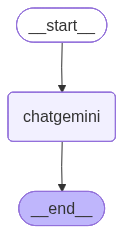

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())